# 02 &mdash; Per-Model Visualizations

Notebook 01 produced the benchmark CSVs and the single-holdout
forecast. This notebook picks up from there: with the multi-origin
results in hand, we look at aggregate behavior across the full
benchmark.

| Section | Figure | Question it answers |
|---|---|---|
| 2 | `mae_convergence.png` | As we add origins (1, 10, 30, 60), does the ranking stabilize? |
| 3 | `mae_final_60.png` | At the 60-origin scale, what does the leaderboard look like zoomed in? |
| 4 | `model_comparison_60.png` | How wide is each model's MAE distribution? Do the means hide tail behavior? |
| 5 | `IBM_vs_RWD.png` | Does the foundation model lose on average *and* most of the time, or just occasionally? |

Every figure here is built from the CSVs exported by notebook 01.
The statistical-significance treatment (Diebold-Mariano, Model
Confidence Set) is in `03_backtest_stats.ipynb`.


## 1. Setup

In [2]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

from coffee_forecast.config import (
    COLOR_MAP,
    PLOT_ORDER,
    CSV_DIR,
    FIG_DIR,
    SCALES,
    CONTEXT_LEN,
    HORIZON,
)

FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
summary = pd.read_csv(CSV_DIR / "summary_all_scales.csv")
step_errors = pd.read_csv(CSV_DIR / "step_errors_all_scales.csv")
print(f"summary_all_scales.csv      : {len(summary):>6} rows")
print(f"step_errors_all_scales.csv  : {len(step_errors):>6} rows")

summary_all_scales.csv      :   1010 rows
step_errors_all_scales.csv  :  63630 rows


## 2. MAE convergence across scales

Each model's mean MAE at scales 1, 10, 30, and 60. The question is
whether the ranking has *stabilized* by scale = 60. If it hasn't,
the statistical tests in notebook 03 would be on shaky ground. The
x-axis is plotted as four equally-spaced ordinal steps (rather than
to scale) so the early ramp from 1 to 10 doesn't get visually
compressed.


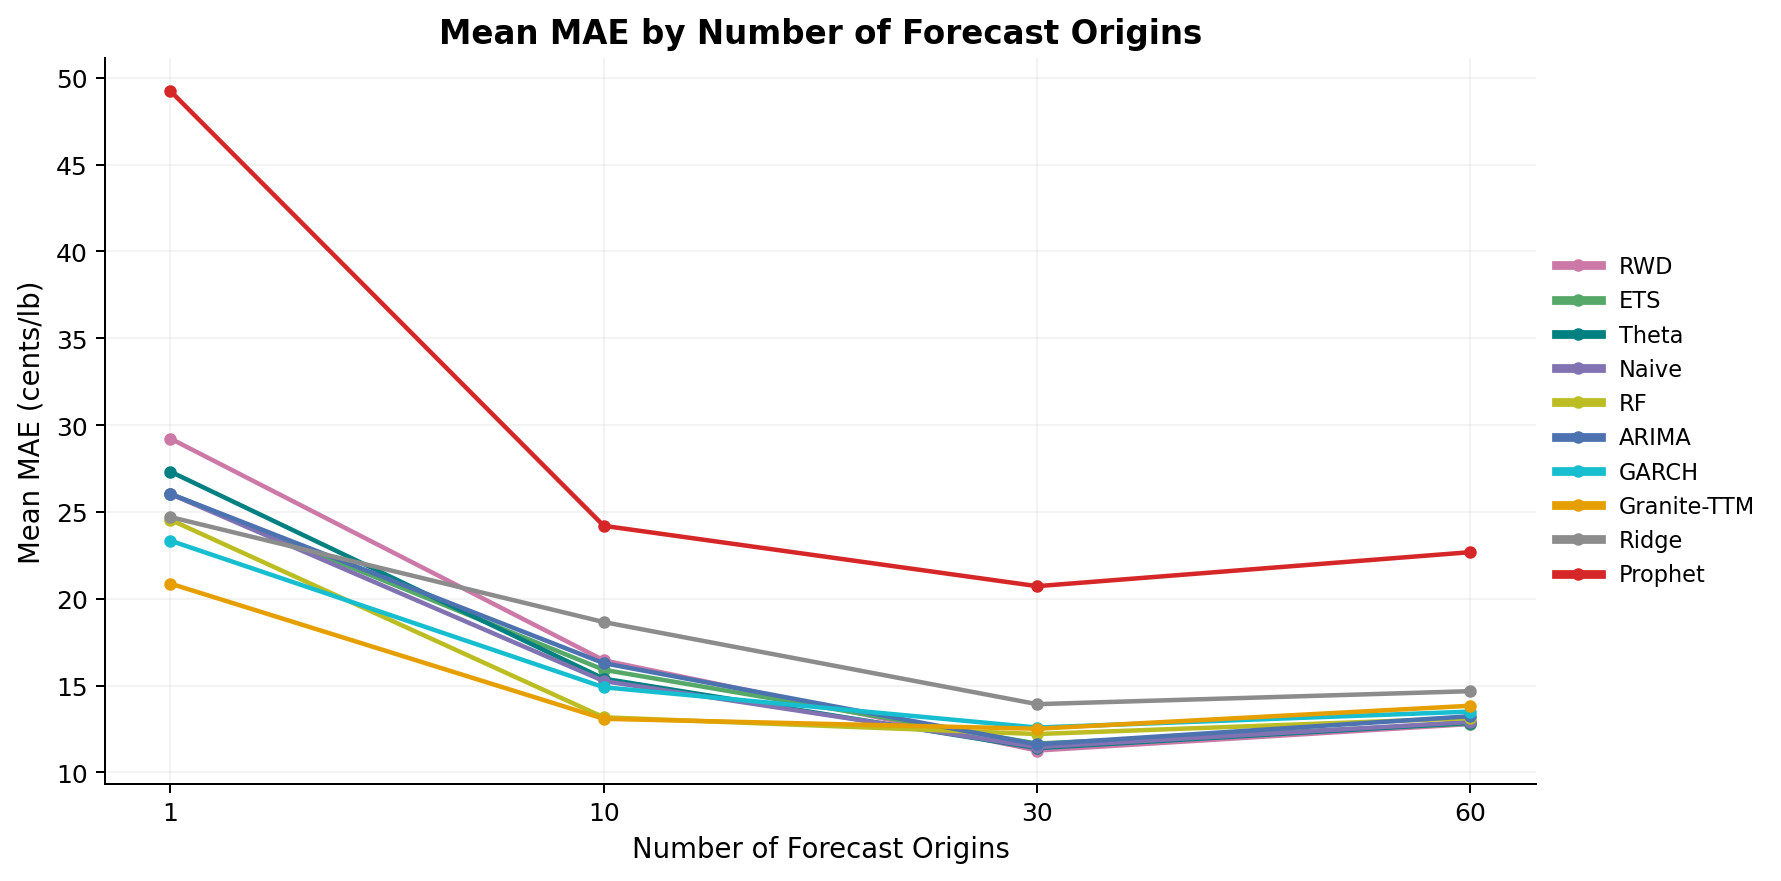

In [4]:
convergence = summary.groupby(["scale", "model"])["MAE"].mean().reset_index()

# Map true scales to equally spaced positions so 1 -> 10 -> 30 -> 60
# reads as four ordinal steps rather than a squashed linear axis.
scale_positions = {s: i for i, s in enumerate(SCALES)}

fig, ax = plt.subplots(figsize=(10, 5), dpi=180)
for name in PLOT_ORDER:
    model_data = convergence[convergence["model"] == name].sort_values("scale")
    x_pos = [scale_positions[s] for s in model_data["scale"]]
    ax.plot(
        x_pos,
        model_data["MAE"],
        marker="o",
        color=COLOR_MAP.get(name, "#666666"),
        linewidth=1.8,
        markersize=4,
        label=name,
    )

ax.set_title("Mean MAE by Number of Forecast Origins", fontsize=13, weight="semibold")
ax.set_xlabel("Number of Forecast Origins", fontsize=11)
ax.set_ylabel("Mean MAE (cents/lb)", fontsize=11)
ax.set_xticks(range(len(SCALES)))
ax.set_xticklabels(SCALES)
ax.grid(True, alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
leg = ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=9)
for line in leg.get_lines():
    line.set_linewidth(3.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "mae_convergence.png", dpi=300, bbox_inches="tight")
plt.show()


**Reading this plot.** The nine non-Prophet models are nearly flat
from scale 30 to scale 60: the ranking has stabilized. Prophet sits
well above the cluster and is visibly noisier across scales. Sixty
origins is enough to resolve the remaining differences. The next
plot drops Prophet and zooms in on the 60-origin column so the
tight cluster of the other nine models is legible.


## 3. MAE at 60 origins, zoomed in

The nine non-Prophet models in isolation, sorted by mean MAE. This
is the same number as the rightmost column of the convergence plot
above (scale = 60), rescaled so the differences are visible.


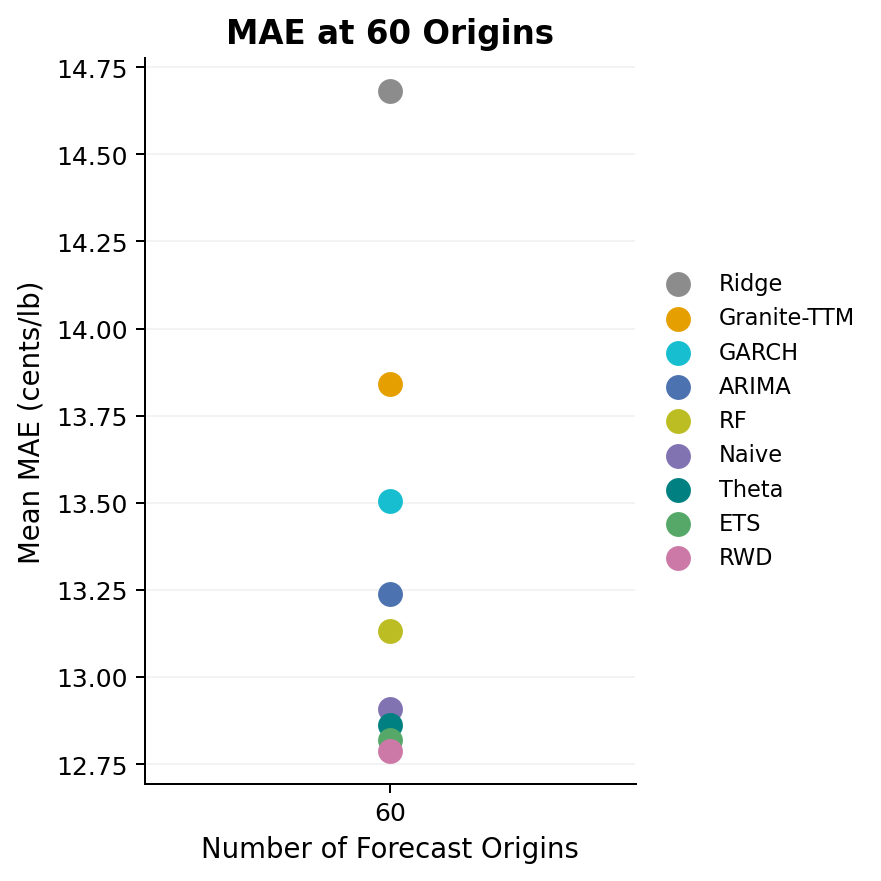

In [5]:
final = convergence[convergence["scale"] == 60].sort_values("MAE", ascending=False)
final = final[final["model"] != "Prophet"]  # Prophet off-scale; dropped for readability

fig, ax = plt.subplots(figsize=(5, 5), dpi=180)
for _, row in final.iterrows():
    ax.scatter(
        60,
        row["MAE"],
        color=COLOR_MAP.get(row["model"], "#666666"),
        s=80,
        zorder=3,
        label=row["model"],
    )

ax.set_ylabel("Mean MAE (cents/lb)", fontsize=11)
ax.set_xlabel("Number of Forecast Origins", fontsize=11)
ax.set_title("MAE at 60 Origins", fontsize=13, weight="semibold")
ax.set_xticks([60])
ax.set_xticklabels(["60"])
ax.set_xlim(55, 65)
ax.grid(True, alpha=0.15, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "mae_final_60.png", dpi=300, bbox_inches="tight")
plt.show()


**Reading this plot.** At 60 origins the nine non-Prophet models
collapse into a vertical band only a few cents/lb wide. The simplest
models in the suite (RWD, Naive, Theta) cluster at the bottom of the
column with the lowest mean MAE; the more sophisticated approaches
(Granite-TTM, Ridge) sit above them. The visual spread is small
relative to the price level (~250 cents/lb on the recent window),
which is exactly the setup that motivates the Diebold-Mariano and
Model Confidence Set tests in the next notebook: the differences are
too small to eyeball.


## 4. MAE distribution at 60 origins

The mean MAE sorts the models, but it can hide fat tails: a model
that's average most of the time but occasionally explodes will look
worse than it deserves, and vice versa. Boxplots show the full
per-origin distribution: median, IQR, whiskers, and individual
origins that fell outside the whiskers.


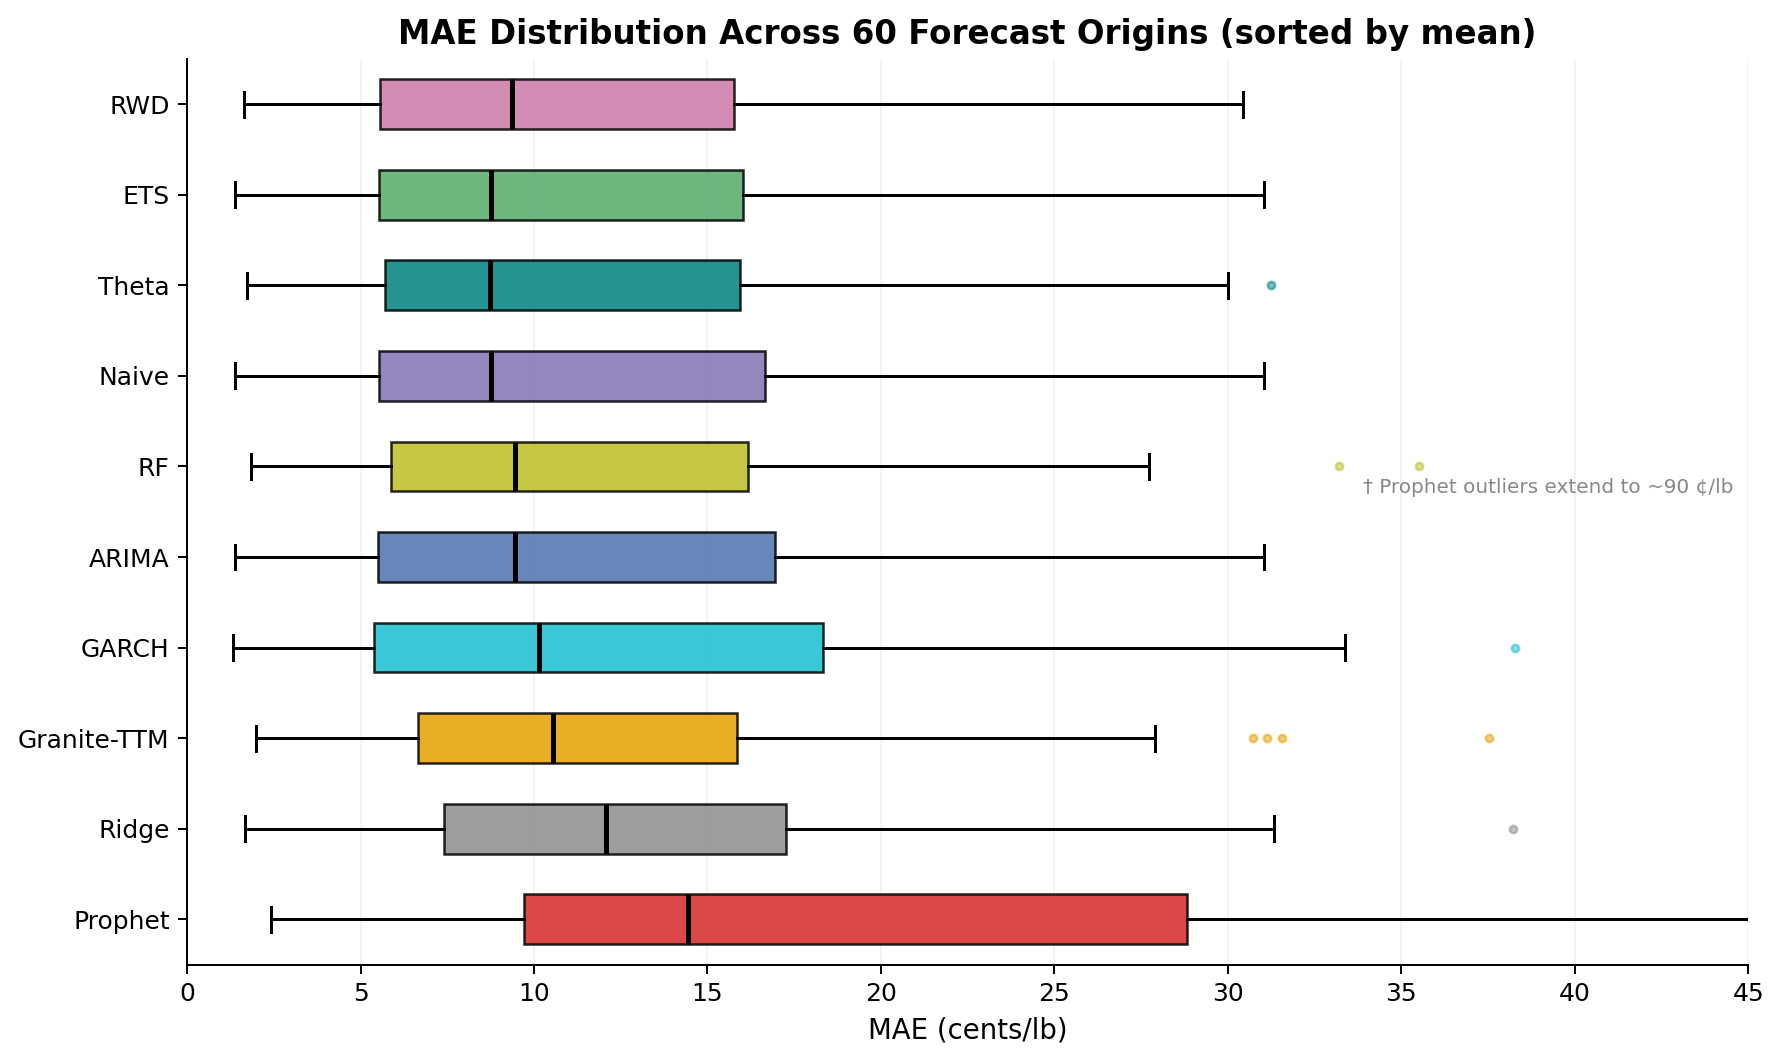

In [6]:
results_60 = summary[summary["scale"] == 60]
order = (
    results_60.groupby("model")["MAE"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
data = [results_60[results_60["model"] == m]["MAE"].values for m in order]

fig, ax = plt.subplots(figsize=(10, 6), dpi=180)
bp = ax.boxplot(
    data,
    vert=False,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker="o", markersize=3, alpha=0.5),
    widths=0.55,
)
for patch, name in zip(bp["boxes"], order):
    patch.set_facecolor(COLOR_MAP.get(name, "#666666"))
    patch.set_alpha(0.85)
for flier, name in zip(bp["fliers"], order):
    flier.set_markerfacecolor(COLOR_MAP.get(name, "#666666"))
    flier.set_markeredgecolor(COLOR_MAP.get(name, "#666666"))

ax.set_xlim(0, 45)
ax.annotate(
    "† Prophet outliers extend to ~90 ¢/lb",
    xy=(45, 0.5),
    xycoords=("data", "axes fraction"),
    ha="right",
    va="bottom",
    fontsize=8,
    color="#888",
    xytext=(-6, 6),
    textcoords="offset points",
)

ax.set_yticklabels(order, fontsize=10)
ax.set_title(
    "MAE Distribution Across 60 Forecast Origins (sorted by mean)",
    fontsize=13,
    weight="semibold",
)
ax.set_xlabel("MAE (cents/lb)", fontsize=11)
ax.grid(True, axis="x", alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "model_comparison_60.png", dpi=300, bbox_inches="tight")
plt.show()

**Reading this plot.** The medians and IQRs of the top nine models
overlap heavily, the visual version of what MCS proved rigorously
(see notebook 03; 9 of 10 models survive in the MCS at α=0.10, only
Prophet eliminated). Granite-TTM is the standout within that cluster:
its IQR is among the tightest, but the whole box sits shifted right
of the leaders, so it's not noisy, just consistently a bit worse.
Prophet's box is shifted right *and* has a much longer right whisker:
it's worse on average *and* more unstable. That's why it's the one
model eliminated from the MCS.


## 5. Per-origin deep dive: IBM Granite TTM vs. RWD

Recall Granite TTM topped the single-window leaderboard back in
`01_backtest_run.ipynb` §4. Across all 60 origins, the picture
flips: it underperforms RWD almost everywhere. The interesting
question is *how* it loses. Does it win often but occasionally
collapse, or does it just underperform across the board? Plotting
per-origin MAE for both models tells that story directly.


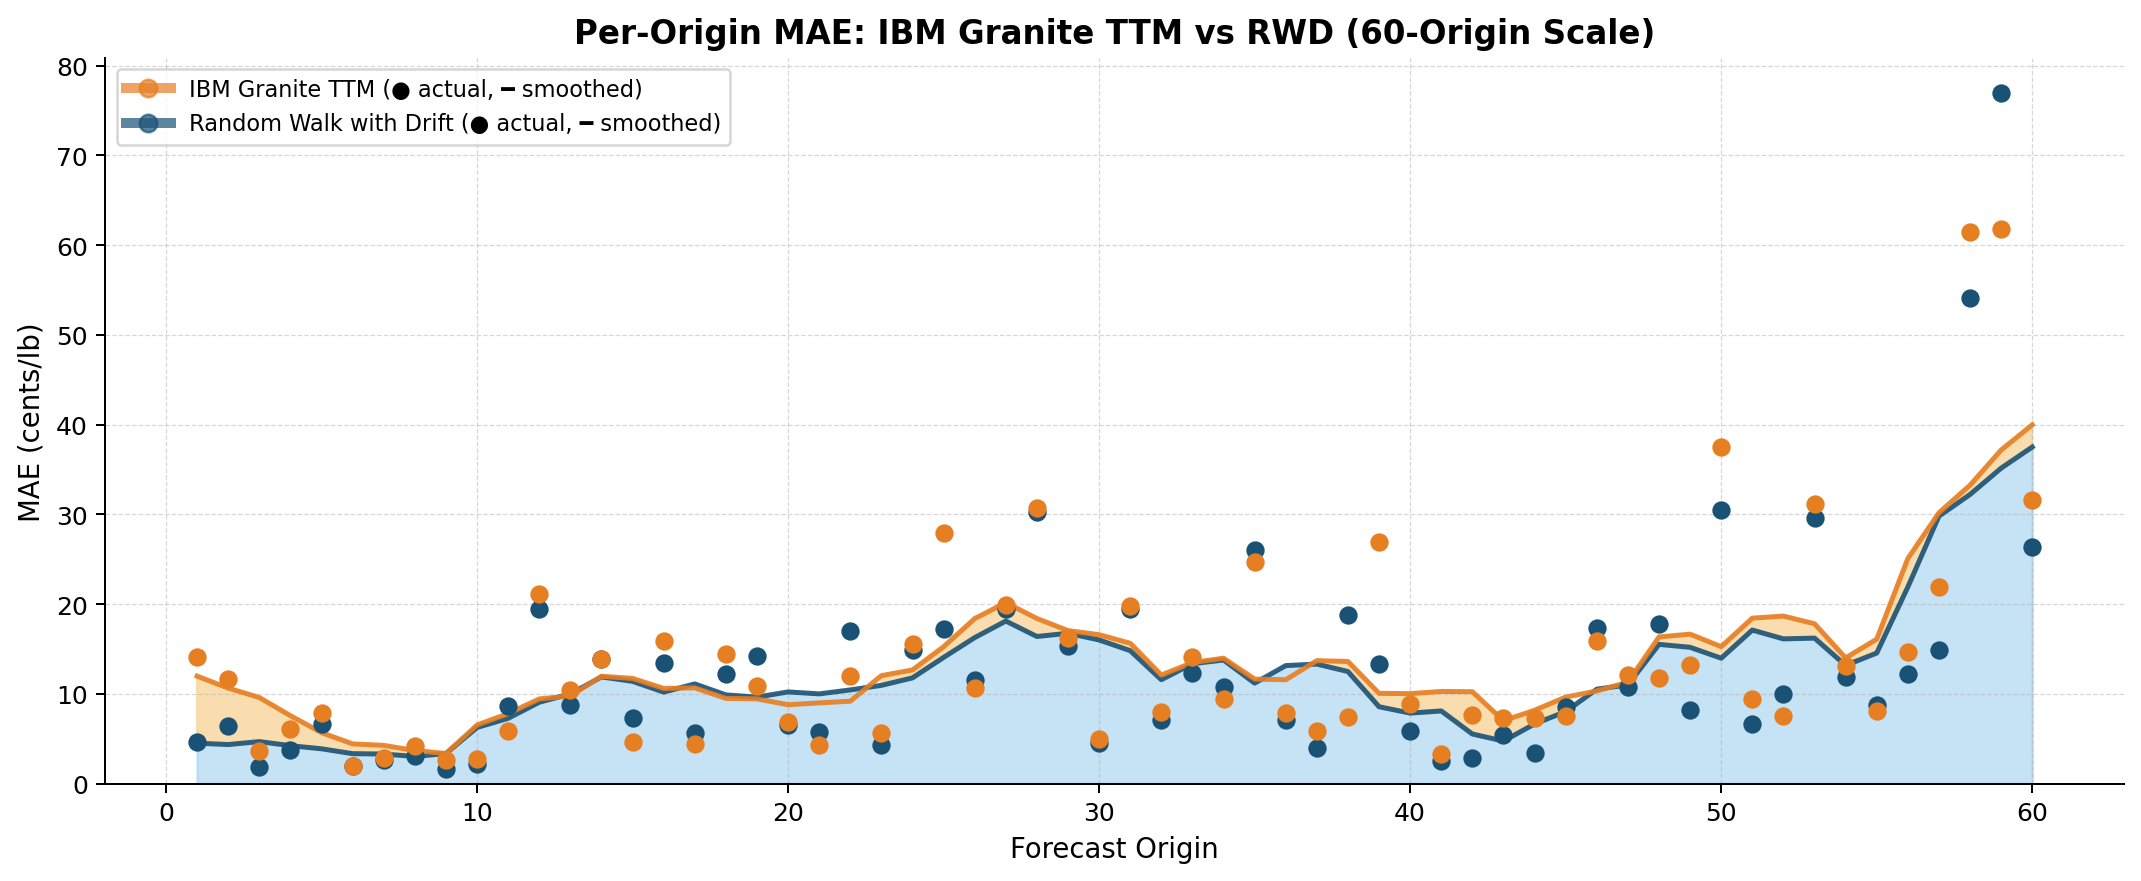


Granite beats RWD in 16 / 60 origins
Mean MAE: Granite = 13.842,  RWD = 12.789


In [7]:
from scipy.ndimage import uniform_filter1d

# Per-origin MAE = mean of per-step absolute errors over the 63-day horizon.
s60 = step_errors[step_errors["scale"] == 60]
rwd_mae = (
    s60[s60["model"] == "RWD"].groupby("origin_id")["error"].mean().sort_index().values
)
gra_mae = (
    s60[s60["model"] == "Granite-TTM"]
    .groupby("origin_id")["error"]
    .mean()
    .sort_index()
    .values
)
origin_ids = np.arange(1, len(rwd_mae) + 1)

# Smoothed trend to cut through origin-to-origin noise.
W = max(5, len(rwd_mae) // 10)
smooth_r = uniform_filter1d(rwd_mae.astype(float), size=W, mode="nearest")
smooth_g = uniform_filter1d(gra_mae.astype(float), size=W, mode="nearest")

fig, ax = plt.subplots(figsize=(12, 5), dpi=180)

# Blue base layer: 0 to RWD trend (shared forecast difficulty).
ax.fill_between(origin_ids, 0, smooth_r, color="#AED6F1", alpha=0.7)
# Orange layer: only where Granite exceeds RWD (the extra error).
ax.fill_between(
    origin_ids,
    smooth_r,
    smooth_g,
    where=(smooth_g >= smooth_r),
    color="#FAD7A0",
    alpha=0.85,
)

ax.plot(origin_ids, smooth_r, color="#1A5276", linewidth=2.0, alpha=0.9)
ax.plot(origin_ids, smooth_g, color="#E67E22", linewidth=2.0, alpha=0.9)
ax.scatter(origin_ids, rwd_mae, color="#1A5276", s=40, zorder=5)
ax.scatter(origin_ids, gra_mae, color="#E67E22", s=40, zorder=5)

ax.set_title(
    "Per-Origin MAE: IBM Granite TTM vs RWD (60-Origin Scale)",
    fontsize=13,
    weight="semibold",
)
ax.set_xlabel("Forecast Origin", fontsize=11)
ax.set_ylabel("MAE (cents/lb)", fontsize=11)
ax.set_ylim(bottom=0)
ax.grid(True, ls="--", linewidth=0.5, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="#E67E22",
        markerfacecolor="#E67E22",
        markersize=7,
        linewidth=4,
        alpha=0.7,
        label="IBM Granite TTM (● actual, ━ smoothed)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="#1A5276",
        markerfacecolor="#1A5276",
        markersize=7,
        linewidth=4,
        alpha=0.7,
        label="Random Walk with Drift (● actual, ━ smoothed)",
    ),
]
ax.legend(handles=legend_handles, loc="upper left", frameon=True, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "IBM_vs_RWD.png", dpi=300, bbox_inches="tight")
plt.show()

granite_wins = int(np.sum(gra_mae < rwd_mae))
print(f"\nGranite beats RWD in {granite_wins} / {len(rwd_mae)} origins")
print(f"Mean MAE: Granite = {gra_mae.mean():.3f},  RWD = {rwd_mae.mean():.3f}")

**Reading this plot.** Granite has lower MAE than RWD at only 16 of
60 origins. The underperformance is not driven by a few outlier
windows; the orange-shaded area (Granite's excess error above RWD) is
nearly continuous, and the smoothed curves rarely cross. Neither the
32-year pretraining corpus nor the 1,536-day context window at each
origin translate into lower point-forecast error on this series.

---

**Next notebook:** `03_backtest_stats.ipynb` &mdash; Diebold-Mariano
tests and the Model Confidence Set on the 60-origin results, to
verify that the tight MAE cluster in the dot plot above is an
actual statistical tie rather than a ranking the sample size
failed to resolve.
